In [69]:
import sympy as sp
from sympy.physics.vector import init_vprinting
init_vprinting(use_latex='mathjax')

In [70]:
t = sp.Symbol("t")

mr, k = sp.symbols("m_r k")

r, theta = sp.symbols('r theta', cls=sp.Function)
r, theta = r(t), theta(t)

L = 1/2 * mr * (r.diff(t)**2 + r**2 * theta.diff(t)**2) + k/r

In [71]:
L.nsimplify()

       ⎛ 2  2    2⎞
k   mᵣ⋅⎝r ⋅θ̇  + ṙ ⎠
─ + ───────────────
r          2       

# 1.a

In [72]:
l = L.diff(theta.diff(t)).nsimplify()
l

    2  
mᵣ⋅r ⋅θ̇

# 1.b

b) Partiendo de la ecuación

$$\dot{r}^2 = \frac{2}{m_r} [E - U_{\text{eff}}(r)], \quad U_{\text{eff}}(r) = \frac{l^2}{2m_r r^2} - \frac{k}{r},$$

e introduciendo la nueva variable $u = 1/r$, demuestre que la energía orbital de la masa reducida se escribe, en las variables $u$ y $\theta$, como

$$E = \frac{l^2}{2m_r} \left[ \left(\frac{du}{d\theta}\right)^2 + u^2 \right] - ku.$$

In [73]:
E = sp.Symbol("E")

Ueff = sp.Function("U_{eff}")(r)
u = sp.Function("u")(theta)

r = 1/u

theta_dot = l / (mr * r**2)
r_dot = r.diff(theta) * theta_dot

eq1 = sp.Eq(Ueff, l**2/(2*mr*r**2) - k/r)
eq2 = sp.Eq(r_dot**2, 2/mr * (E - Ueff))


eq_combinada = eq2.subs(Ueff, eq1.rhs)

E_despejada = sp.solve(eq_combinada, E)[0]

display(E_despejada.expand())

                                              2
                               4  2 ⎛d       ⎞ 
              4  2     2   mᵣ⋅r ⋅θ̇ ⋅⎜──(u(θ))⎟ 
          mᵣ⋅r ⋅u (θ)⋅θ̇             ⎝dθ      ⎠ 
-k⋅u(θ) + ────────────── + ────────────────────
                2                   2          

Expresión numérica de la Energía Total: -0.375000000000000


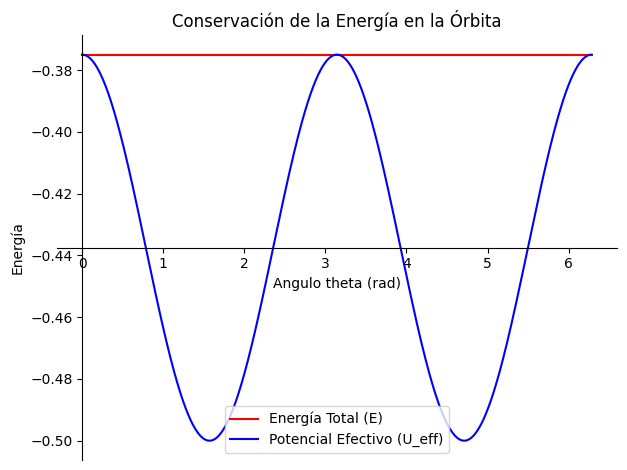

In [60]:
import sympy as sp
from sympy.plotting import plot

# 1. Definir símbolos y funciones
theta = sp.Symbol('theta')
E = sp.Symbol('E')

# 2. Asignar valores numéricos modestos a las constantes
valores = {
    'm_r': 1,      # Masa reducida unitaria
    'k': 1,        # Constante de acoplamiento gravitatoria/electrostática
    'l': 1,        # Momento angular
    'A': 0.5       # Amplitud de la oscilación (relacionada con la excentricidad)
}

# Símbolos individuales para la sustitución
mr_s, k_s, l_s, A_s = sp.symbols('m_r k l A')

# 3. Definir u(theta) y su derivada basadas en la solución real
u = (mr_s * k_s) / l_s**2 + A_s * sp.cos(theta)
du_dtheta = u.diff(theta)

# 4. Expresión de la Energía del ítem b)
E_expr = (l_s**2 / (2 * mr_s)) * (du_dtheta**2 + u**2) - k_s * u

# Sustituir los valores numéricos
E_num = E_expr.subs(valores)
U_eff_num = ((l_s**2 / (2 * mr_s)) * u**2 - k_s * u).subs(valores) # Energía potencial efectiva

print(f"Expresión numérica de la Energía Total: {sp.simplify(E_num)}")

# 5. Graficar con el módulo plot de SymPy
p = plot(E_num, U_eff_num, (theta, 0, 2 * sp.pi), 
         title="Conservación de la Energía en la Órbita",
         xlabel="Angulo theta (rad)", 
         ylabel="Energía", 
         label=["Energía Total (E)", "Potencial Efectivo (U_eff)"],
         legend=True, 
         show=False)

# Cambiar colores de las curvas para distinguirlas
p[0].line_color = 'red'   # Energía Total constante
p[1].line_color = 'blue'  # Componente variable

p.show()

In [81]:
E = (l**2 / (2 * mr)) * (u.diff(theta)**2 + u**2) - k * u
E

             ⎛                  2⎞
           2 ⎜ 2      ⎛d       ⎞ ⎟
          l ⋅⎜u (θ) + ⎜──(u(θ))⎟ ⎟
             ⎝        ⎝dθ      ⎠ ⎠
-k⋅u(θ) + ────────────────────────
                    2⋅mᵣ          

In [99]:
edo = sp.simplify(sp.Eq(E.diff(theta) * mr / u.diff(theta) / l**2,0))
edo

                 2           
  k⋅mᵣ          d            
- ──── + u(θ) + ───(u(θ)) = 0
    2             2          
   l            dθ           

In [103]:
solucionEdo = sp.dsolve(edo,u)
solucionEdo

                               k⋅mᵣ
u(θ) = C₁⋅sin(θ) + C₂⋅cos(θ) + ────
                                 2 
                                l  